In [19]:


from datasets import load_dataset
import duckdb as ddb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datetime import datetime


# Cell 2: Import your modules
import utilities.aggregate_customers as agg
import utilities.visualize_energy_consumption as viz

import utilities.wind_farm_analysis as wind

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 7)

print("✓ All imports successful")

✓ All imports successful


In [15]:
# Load dataset
ds = load_dataset("thuml/UTSD", "UTSD-2G")
df = pd.DataFrame(ds['train'])

# Filter for smart meter data
con = ddb.connect()

Resolving data files:   0%|          | 0/320 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

UTSD-2G/data-00004-of-00080.arrow:   0%|          | 0.00/15.1M [00:00<?, ?B/s]

UTSD-2G/data-00002-of-00080.arrow:   0%|          | 0.00/3.43M [00:00<?, ?B/s]

UTSD-2G/data-00011-of-00080.arrow:   0%|          | 0.00/3.81M [00:00<?, ?B/s]

...

UTSD-2G/data-00076-of-00080.arrow:   0%|          | 0.00/2.87M [00:00<?, ?B/s]

UTSD-2G/data-00077-of-00080.arrow:   0%|          | 0.00/2.87M [00:00<?, ?B/s]

UTSD-2G/data-00078-of-00080.arrow:   0%|          | 0.00/5.35M [00:00<?, ?B/s]

UTSD-2G/data-00079-of-00080.arrow:   0%|          | 0.00/262M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [16]:
wind_farm_df = con.execute("""
    SELECT * FROM df WHERE item_id LIKE '%Energy_wind%';
""").fetch_df()

print(f"Loaded {len(wind_farm_df)} customer time series")
wind_farm_df.head(n = 5)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded 1 customer time series


,item_id,start,end,freq,target
0,Energy_wind_4_seconds_dataset_0_0,2019-08-01T00:00:03.000000000,2020-01-19T05:31:31.000000000,S,"[18.600000381469727, 18.600000381469727, 18.60..."


In [20]:
row = wind_farm_df.iloc[0]
print(len(row['target']))

interval_info = wind.detect_time_interval(row)
print(f"Interval: {interval_info['interval_str']}")

3698573
Interval: 4s


In [21]:
# Complete analysis
results = wind.analyze_wind_data(row)
wind_df = results['wind_df']
daily_stats = results['daily_stats']

WIND FARM DATA ANALYSIS

Step 1: Detecting time interval...

Time Series Information:
  Start: 2019-08-01 00:00:03
  End: 2020-01-19 05:31:31
  Duration: 171 days 05:31:28
  Data points: 3,698,573
  Interval: 4s
  Frequency (pandas): 4s
  Frequency (dataset): 'S'

Step 2: Expanding time series...
  Created DataFrame with 3,698,573 rows

Step 3: Calculating daily statistics...
  Generated statistics for 172 days

Overall Statistics:
  Mean power: 43.77 MW
  Median power: 34.30 MW
  Std dev: 37.45 MW
  Min power: -1.50 MW
  Max power: 129.30 MW

Daily Statistics:
  Avg daily mean: 43.77 MW
  Avg daily total: 941155.68 MWh
  Peak daily mean: 104.95 MW
  Lowest daily mean: 2.26 MW


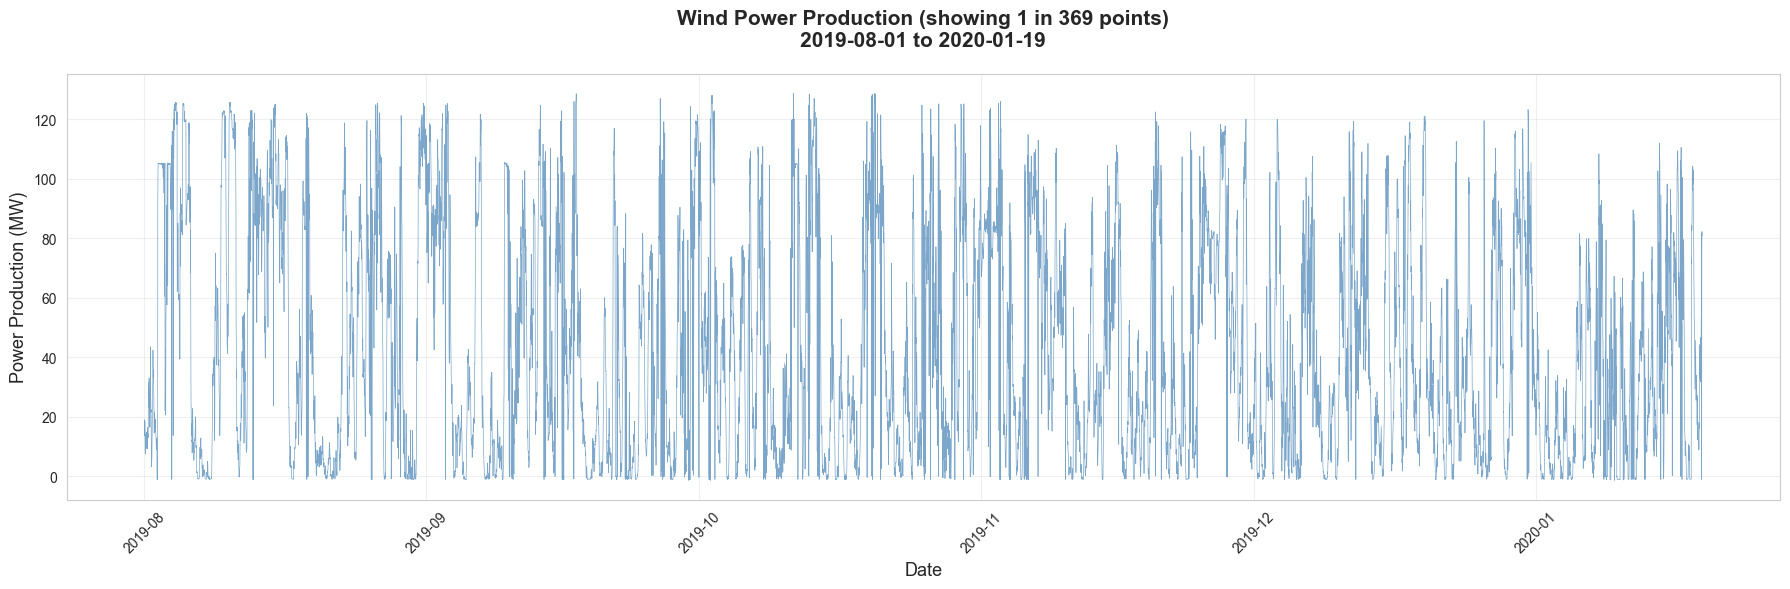

In [22]:
# 1. Full time series
wind.plot_full_timeseries(wind_df)
plt.show()

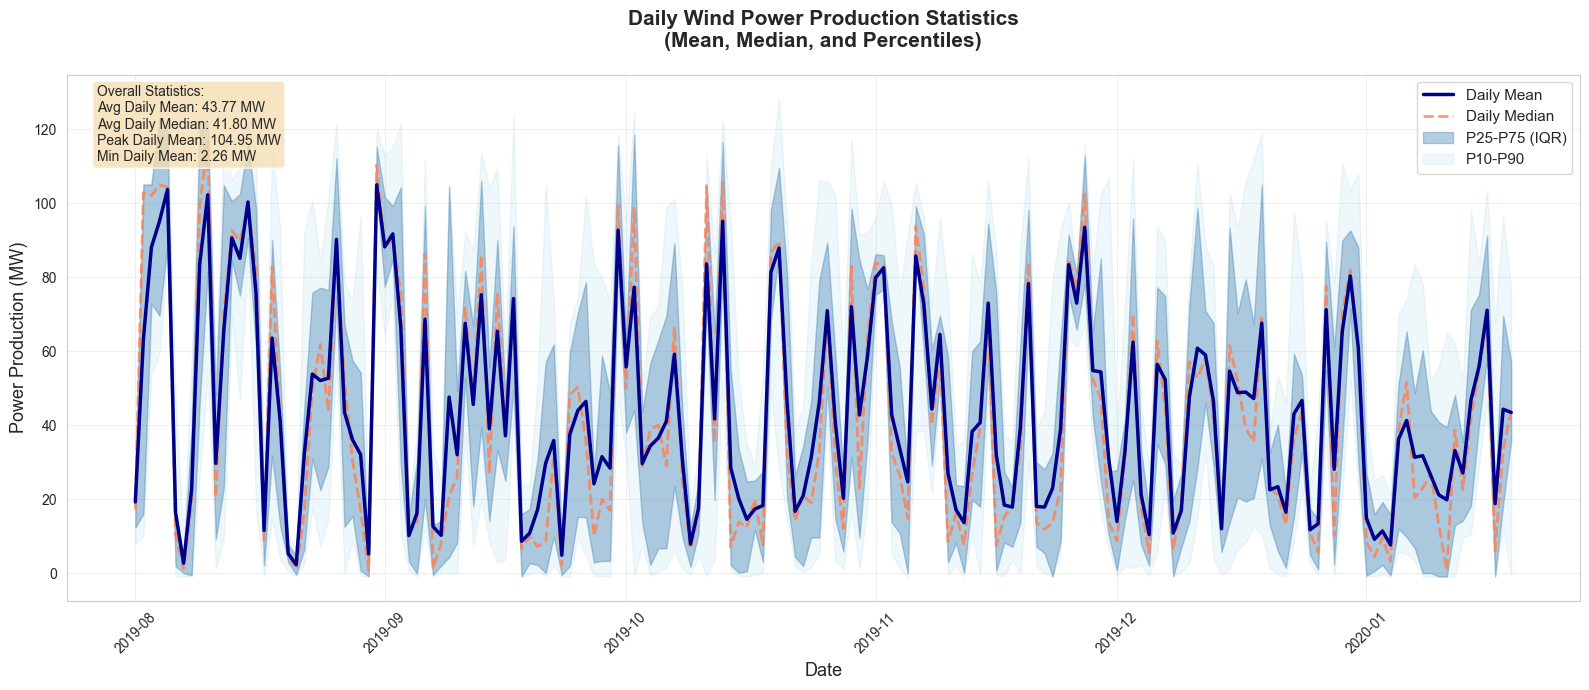

In [23]:
# 2. Daily statistics with percentiles
wind.plot_daily_statistics(daily_stats)
plt.show()

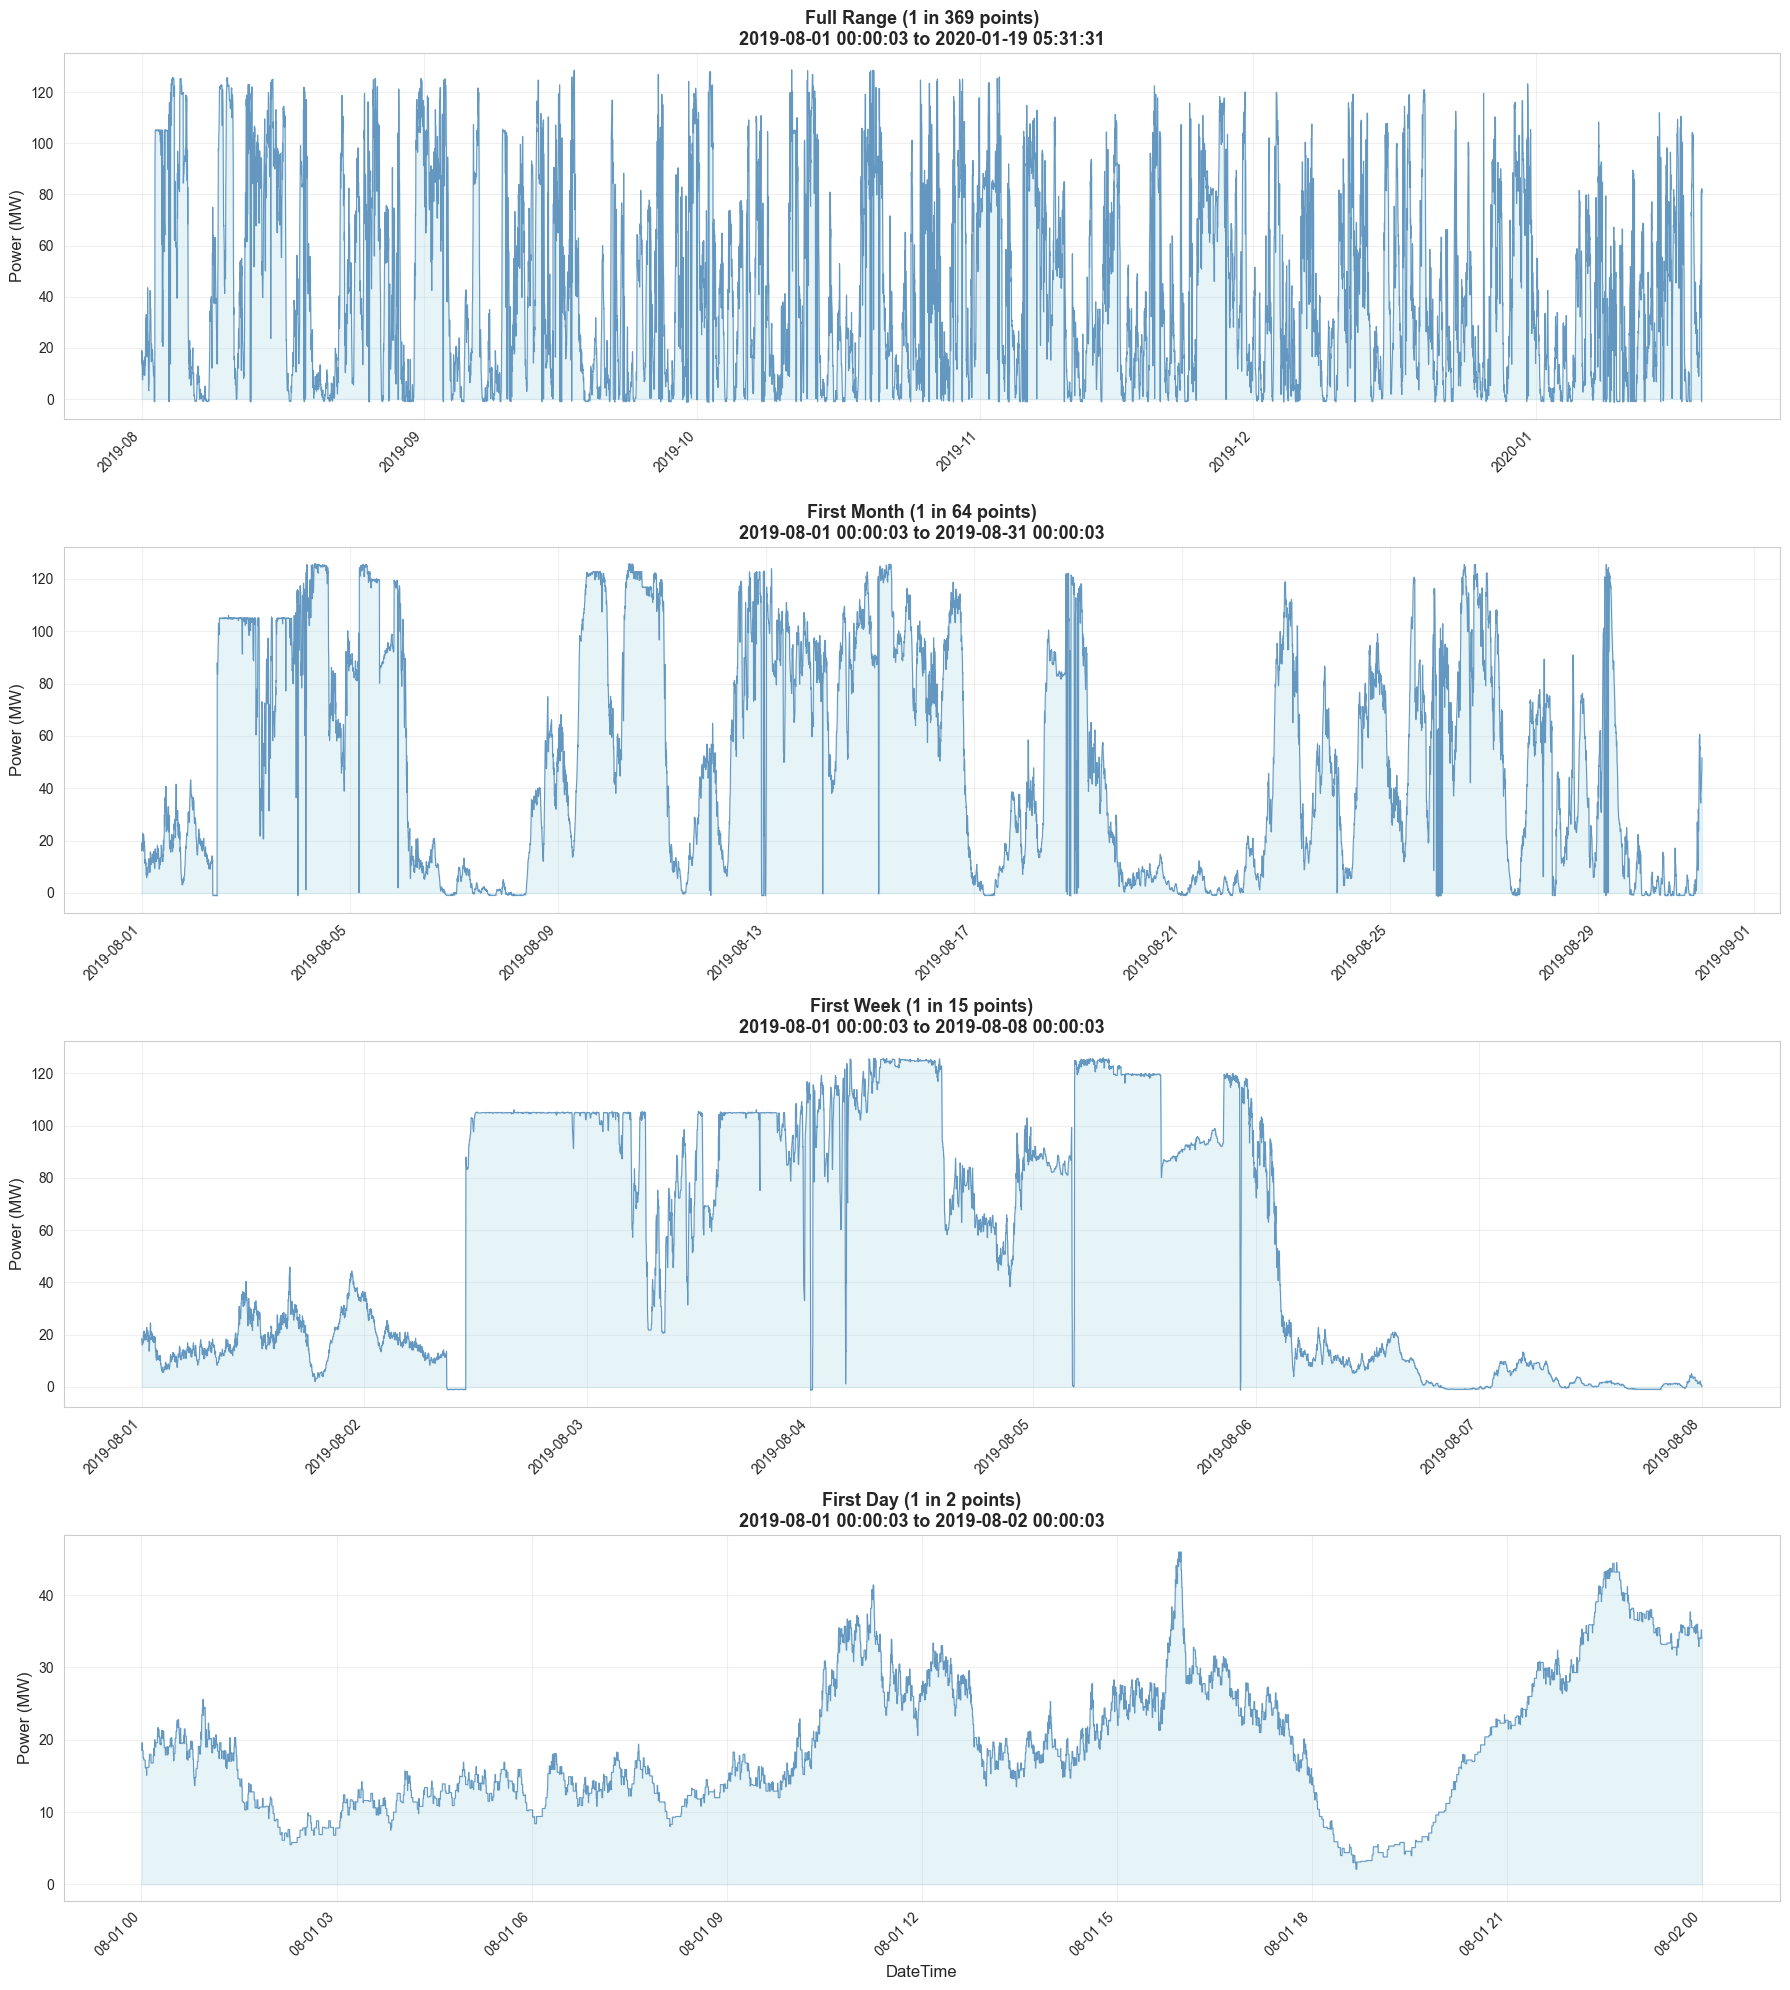

In [24]:
# 3. Multi-resolution view (varying granularity!)
wind.plot_multi_resolution_view(wind_df)
plt.show()

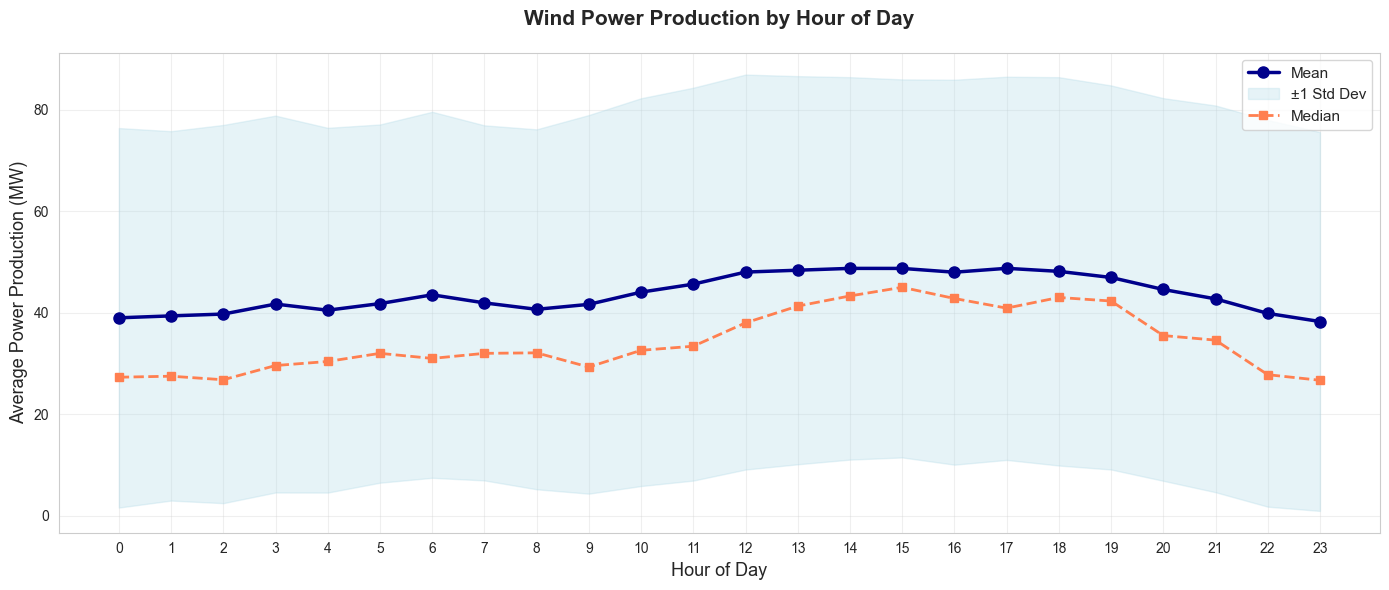

In [25]:
# 4. Hourly patterns
wind.plot_hourly_patterns(wind_df)
plt.show()

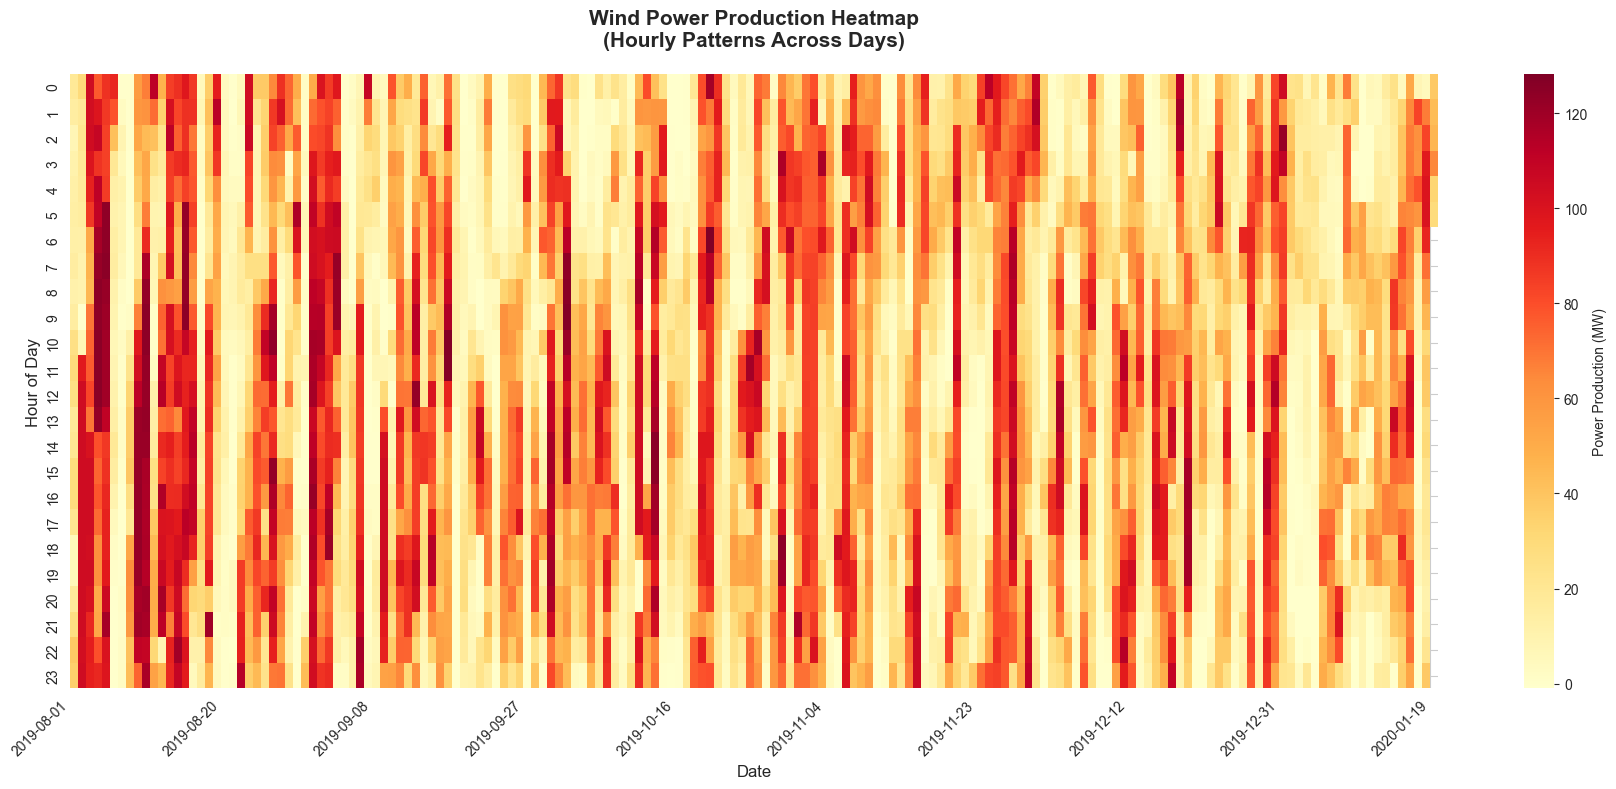

In [26]:
# 5. Heatmap
wind.plot_daily_production_heatmap(wind_df)
plt.show()